**Raquel del Valle Olivares y Xiya Ye**

![LogoUC3M](https://login.uc3m.es/imgs/uc3m.png)


## 1. EDA y modelos
### 1.1. Carga de datos
Lo primero que vamos a hacer es realizar un Análisis Exploratorio de Datos (EDA). Para ello, necesitamos tener instaladas la librería de *pandas*, además, vamos a instalar otras librería que vamos a necesitar más adelante, como la *matplotlib*, *seaborn* y *scikit-learn*.

In [1]:
%pip install pandas matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


A continuación, procedemos a cargar los datos para el entrenamiento y análisis. Cargamos el archivo *bank_14.pkl* utilizando la librería *pandas*.

In [2]:
import pandas as pd

df = pd.read_pickle('bank_14.pkl')
display(df)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,-1,0,unknown,no
11158,39,services,married,secondary,no,733,no,no,unknown,16,jun,83,4,-1,0,unknown,no
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,-1,0,unknown,no
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,may,9,2,172,5,failure,no


## 2. EDA Simplificado
### 2.1. Tamaño del conjunto de datos y tipos de variables
Lo primero que debemos conocer es el volumen de datos con el que vamos a trabajar y de qué tipo es cada una de las características (columnas) de nuestros clientes.

In [3]:
# Número de filas (instancias) y columnas (variables)
print(f"El conjunto de datos tiene {df.shape[0]} instancias y {df.shape[1]} variables.\n")

# Tipos de datos de cada columna
print("Tipos de variables en el dataset")
print(df.dtypes)

El conjunto de datos tiene 11000 instancias y 17 variables.

Tipos de variables en el dataset
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
deposit      object
dtype: object


Como podemos observar, tenemos un conjunto de 11 000 clientes y 17 variables en total. Además, vemos que hay una mezcla de variables numéricas (marcadas como *int64*, por ejemplo la edad o el balance de cuenta) y variables categóricas o de texto (marcadas como *object*, por ejemplo el tipo de trabajo, el estado civil o nivel de educación). 

### 2.2. Valores faltantes y columnas inútiles (constantes o IDs)
En este paso, vamos a comprobar la calidad de nuestros datos. Buscaremos si hay información incompleta (valores nulos o faltantes) usando las funciones básicas de Pandas. También comprobaremos si hay columnas que no aportan información al modelo: las constantes (tienen el mismo valor para todos los clientes) o las de tipo ID (tienen un valor distinto y único para cada cliente).

In [4]:
print("VALORES FALTANTES")
faltantes = df.isnull().sum()
# Filtramos para mostrar solo las columnas que tienen algún valor faltante
columnas_con_faltantes = faltantes[faltantes > 0]
if not columnas_con_faltantes.empty:
    print(columnas_con_faltantes)
else:
    print("No hay valores faltantes en ninguna columna.")

print("\nCOLUMNAS CONSTANTES O DE ID")
valores_unicos = df.nunique()
print("Columnas con 1 solo valor (constantes):", list(valores_unicos[valores_unicos == 1].index))
print("Columnas con todos los valores distintos (posibles IDs):", list(valores_unicos[valores_unicos == len(df)].index))

VALORES FALTANTES
job        174
marital    340
dtype: int64

COLUMNAS CONSTANTES O DE ID
Columnas con 1 solo valor (constantes): []
Columnas con todos los valores distintos (posibles IDs): []


Al ejecutar el código, detectamos que tenemos valores faltantes en algunas variables (por ejemplo, en la columna *job* nos faltan datos de 174 clientes). Esto significa que en la fase de preprocesamiento, antes de entrenar modelos como KNN o Árboles, tendremos que decidir qué hacer con esos huecos. Por otro lado, no hemos detectado columnas constantes ni columnas de identificación (IDs) puras, lo cual es positivo, ya que no tendremos que eliminar columnas inútiles por este motivo.

### 2.3. Alta cardinalidad y análisis de la variable objetivo
A continuación, vamos a revisar si alguna de nuestras variables categóricas tiene "alta cardinalidad" (es decir, si tiene más de 10 categorías o valores únicos distintos)

Finalmente, determinaremos formalmente si estamos ante un problema de clasificación o regresión, y revisaremos las proporciones de nuestra variable objetivo (*deposit*) para saber si está desbalanceada.

In [5]:
print("ALTA CARDINALIDAD EN CATEGÓRICAS (>10 valores únicos)")
# Filtramos para quedarnos solo con las columnas de tipo texto (object)
categoricas = df.select_dtypes(include=['object'])
cardinalidad = categoricas.nunique()

# Buscamos las que tienen estrictamente más de 10
alta_card = cardinalidad[cardinalidad > 10]
if not alta_card.empty:
    print("Variables con más de 10 valores únicos:")
    print(alta_card)
else:
    print("Ninguna variable categórica tiene más de 10 valores únicos.")

print("\nTIPO DE PROBLEMA Y BALANCE DE LA CLASE")
print("El objetivo es predecir la variable 'deposit' (yes/no), por lo que es un problema de CLASIFICACIÓN.")
print("Balance de la variable 'deposit' (%):")
# normalize=True nos da la proporción sobre 1, lo multiplicamos por 100 para ver el %
print(df['deposit'].value_counts(normalize=True) * 100)

ALTA CARDINALIDAD EN CATEGÓRICAS (>10 valores únicos)
Variables con más de 10 valores únicos:
job      12
month    12
dtype: int64

TIPO DE PROBLEMA Y BALANCE DE LA CLASE
El objetivo es predecir la variable 'deposit' (yes/no), por lo que es un problema de CLASIFICACIÓN.
Balance de la variable 'deposit' (%):
deposit
no     52.545455
yes    47.454545
Name: proportion, dtype: float64


Al ejecutar el código, detectamos que tenemos un par de variables categóricas con alta cardinalidad (por ejemplo, *job* y *month*).

Por otro lado, confirmamos que estamos resolviendo un problema de clasificación. Observando el balance de la variable *deposit*, vemos que las clases están muy equilibradas (aproximadamente un 52% para "no" y 47% para "yes"). Por tanto, el dataset no está desbalanceado

### 2.4. Análisis de la variable *pdays*
Según el diccionario de datos, esta variable indica el número de días desde que el cliente fue contactado en la campaña anterior, utilizando el valor -1 para indicar que el cliente no tiene contacto previo. Así que vamos a ver cuántos clientes están en esta situación.

In [6]:
print("ANÁLISIS DE LA VARIABLE pdays")
# Contamos cuántos clientes tienen pdays = -1
num_no_contactados = (df['pdays'] == -1).sum()
porcentaje = (num_no_contactados / len(df)) * 100

print(f"Clientes con pdays = -1 (no contactados previamente): {num_no_contactados} ({porcentaje:.2f}% del total)")

# Vemos cómo se distribuyen los días de los que SÍ fueron contactados
print("\nEstadísticas de los clientes que SÍ fueron contactados (pdays > -1):")
display(df[df['pdays'] != -1]['pdays'].describe())

ANÁLISIS DE LA VARIABLE pdays
Clientes con pdays = -1 (no contactados previamente): 8203 (74.57% del total)

Estadísticas de los clientes que SÍ fueron contactados (pdays > -1):


count    2797.000000
mean      204.718627
std       122.397953
min         1.000000
25%        98.000000
50%       182.000000
75%       286.000000
max       854.000000
Name: pdays, dtype: float64

Como vemos, una inmensa mayoría de los clientes tiene el valor -1 en pdays. Si introducimos este -1 directamente en algoritmos basados en distancias (como KNN), el modelo interpretará matemáticamente que un cliente no contactado (-1) es muy similar a un cliente contactado ayer (1). 

## 3. Métodos de evaluación
### 3.1. Partición Holdout y elección de la métrica adecuada
Para la elección de la métrica, tenemos en cuneta 2 cosas:
- El tipo de problema: como hemos visto antes, es un problema de clasificación.
- Las clases no están desbalanceadas.

Para un problema de clasificación con las clases equilibradas consideramos que la métrica más directa y adecuada es el Accuracy.


In [7]:
from sklearn.model_selection import train_test_split
# Separamos características (X) y variable objetivo (y)
X = df.drop('deposit', axis=1)
y = df['deposit']

# Ponemos uno de los NIAs como semilla para garantizar reproducibilidad
nia_semilla = 100522214

# Dividimos en conjunto de entrenamiento (2/3) y prueba (1/3)
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=1/3, 
    random_state=nia_semilla
)

print(f"Tamaño del conjunto de entrenamiento: {X_train.shape[0]} instancias")
print(f"Tamaño del conjunto de test: {X_test.shape[0]} instancias")

Tamaño del conjunto de entrenamiento: 7333 instancias
Tamaño del conjunto de test: 3667 instancias


Hemos apartado 1/3 de los datos que actuarán como evaluación outer. Este conjunto no lo usaremos durante el entrenamiento ni el ajuste, lo guardamos para estimar el rendimiento futuro del modelo al final de la práctica.

### 3.2. Evaluación interna (inner)
Se ha optado por utilizar 3 particiones para la evaluación interna con el fin de optimizar el equilibrio entre rigor estadístico y coste computacional. 3 particiones garantizan conjuntos de validación robustos y además, reduce significativamente el tiempo total de ejecución frente a particiones de mayor tamaño. 

In [8]:
from sklearn.model_selection import KFold

# Definimos inner: 3-Fold-Cross-Validation 
inner = KFold(n_splits=3 , shuffle=True, random_state=nia_semilla)

## 4. Métodos Básicos: KNN y TREES
### 4.1. Procedimiento inicial y tratamiento de pdays
Antes de aplicar KNN, debemos preparar los datos. Anteriormente hemos observado que la variable *pdays* tiene más de la mitad de valores -1 que indican que nunca se ha contactado a ese cliente, lo cual es un problema. 

Para solucionarlo, creamos una nueva variable binaria *contactado_previamente* y en las filas en las que *pdays* tenga el valor -1 pondremos un 0 y si por el contrario, el cliente ha sido contactado, pondremos un 1.

In [9]:
import pandas as pd
import numpy as np

# Función para preprocesar pdays sin leakage
def preprocesar_pdays(df_in):
    df_out = df_in.copy()
    # 1 -> contactado; 0 -> no contactado
    df_out['contactado_previamente'] = (df_out['pdays'] != -1).astype(int)
    df_out.loc[df_out['pdays'] == -1, 'pdays'] = 0
    return df_out

# Aplicamos la transformacion a Train y Test
X_train = preprocesar_pdays(X_train) 
X_test = preprocesar_pdays(X_test) 

### 4.2. Mejor método de escalado para KNN
Para decidir cual es el mejor método de escalado (MinMax, Standatd, Robust), evaluaremos los pipelines de cada uno de ellos utilizando la validación interna de 3 particiones y la métrica Accuracy.

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

# Separamos nombres de columnas por tipos
vars_num = X_train.select_dtypes(include=['int64', 'float64', 'int32']).columns.tolist()
vars_cat = X_train.select_dtypes(include=['object']).columns.tolist()

# Definimos el transformador para variables categóricas
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),   # Imputamos nulos con la moda
    ('onehot', OneHotEncoder(handle_unknown='ignore'))      # Codificamos a números
])

# Diccionario con los 3 scalers a evaluar
scalers_a_probar = {
    'Standard': StandardScaler(),
    'MinMax': MinMaxScaler(),
    'Robust': RobustScaler()
}

resultados_scalers = {}

# Construimos y evaluamos el pipeline de cada scaler
for nombre, scaler in scalers_a_probar.items():
    num_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),       # Imputamos nulos numéricos si los hay
        ('scaler', scaler)                                  # Aplicamos scaler
    ])

    # Ensamblamos ambos transformadores
    preprocessor = ColumnTransformer(transformers=[
        ('num', num_transformer, vars_num),
        ('cat', cat_transformer, vars_cat)
    ])

    # pipeline final: preproceso + KNN con hiperparámetros por defecto
    pipeline_knn = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', KNeighborsClassifier())
    ])

    # Evaluamos usando la partición inner definida anteriormente
    # Usamos accuracy como scoring al ser un problema de clasificación
    scores = cross_val_score(pipeline_knn, X_train, y_train, cv=inner, scoring='accuracy')

    # Guardamos la media de las 3 particiones
    resultados_scalers[nombre] = scores.mean()

# Mostramos los resultados
print("Comparativa de scalers para KNN\n")
for nombre, score in resultados_scalers.items():
    print(f"{nombre}: {score: .4f}")

mejor_scaler_nombre = max(resultados_scalers, key=resultados_scalers.get)
mejor_scaler_obj = scalers_a_probar[mejor_scaler_nombre]
print(f"\n El mejor scaler es: {mejor_scaler_nombre}")

Comparativa de scalers para KNN

Standard:  0.7963
MinMax:  0.7337
Robust:  0.7918

 El mejor scaler es: Standard


Siguiendo la metodología de evaluación, determinamos mediante validación cruzada que el método de escalado óptimo es el Standard ya que es el scaler con mayor Accuracy medio (0,7963).

### 4.3. Evaluación de KNN y Árboles con hiperparámetros por defecto
A continuación, evaluaremos el rendimiento de los modelos básicos (KNN y Árboles de Decisión) utilizando las configuraciones del StandarScaler.

*Los árboles de decisión son invariantes a la escala, por lo que no necesitan escalado de variables numéricas. Sin embargo, como la implementación de Scikit-Learn no maneja variables categóricas directamente, por lo que para el árbol mantendremos el One-Hot Encoding y la imputación de nulos. Además, mediremos el tiempo computacional que requiere cada modelo para ser evaluado mediante validación cruzada.*

In [11]:
import time
from sklearn.tree import DecisionTreeClassifier

# Procesador para Árboles (sin scaler)
num_transformer_tree = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

preprocessor_tree = ColumnTransformer(transformers=[
    ('num', num_transformer_tree, vars_num),
    ('cat', cat_transformer, vars_cat)
])

pipeline_tree = Pipeline(steps=[
    ('preprocessor', preprocessor_tree),
    ('classifier', DecisionTreeClassifier(random_state=nia_semilla))
])

# Reconstruimos el Pipeline de KNN con el mejor scaler (Standard)
num_transformer_knn = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor_knn = ColumnTransformer(transformers=[
    ('num', num_transformer_knn, vars_num),
    ('cat', cat_transformer, vars_cat)
])

pipeline_knn = Pipeline(steps=[
    ('preprocessor', preprocessor_knn),
    ('classifier', KNeighborsClassifier())
])

# Evaluación de KNN por defecto
start_time = time.time()
scores_knn_def = cross_val_score(pipeline_knn, X_train, y_train, cv=inner, scoring='accuracy')
time_knn_def = time.time() - start_time

# Evaluación de Árboles por defecto
start_time = time.time()
scores_tree_def = cross_val_score(pipeline_tree, X_train, y_train, cv=inner, scoring='accuracy')
time_tree_def = time.time() - start_time

print("Modelos con hiperparámetros por defecto.\n")
print(f"KNN (StandardScaler) -> Accuracy medio: {scores_knn_def.mean(): .4f} | Tiempo: {time_knn_def: .4f} s")
print(f"Decision Tree -> Accuracy medio: {scores_tree_def.mean(): .4f} | Tiempo: {time_tree_def: .4f} s")


Modelos con hiperparámetros por defecto.

KNN (StandardScaler) -> Accuracy medio:  0.7963 | Tiempo:  0.4702 s
Decision Tree -> Accuracy medio:  0.7755 | Tiempo:  0.3840 s


Una de las principales ventajas de los árboles de decisión frente a otros métodos como KNN o RNA es que son modelos interpretables. Los atributos que aparecen más deca de la raíz del árbol son los más relevantes para discriminar entre clases.

Para ilustrar de forma clara las decisiones del modelo, vamos a entrenar un árbol muy poco profundo (max_depth=2) y a visualizar el grafo resultante.

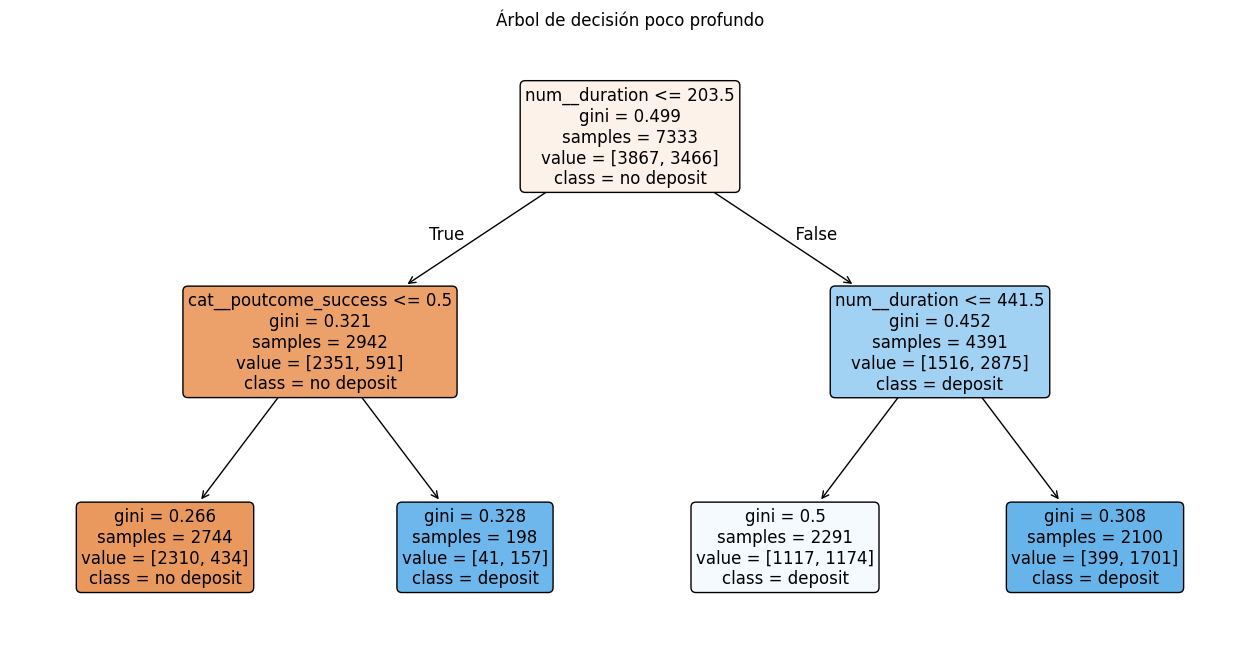

In [12]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Creamos un pipeline con un árbol poco profundo (profundidad máxima = 2)
shallow_tree_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_tree),
    ('classifier', DecisionTreeClassifier(max_depth=2, random_state=nia_semilla))
])

# Ajustamos el modelo sobre todo el conjunto de entrenamiento
shallow_tree_pipeline.fit(X_train, y_train)

# Extraemos el modelo de árbol entrenado y los nombres de las variables
modelo_arbol = shallow_tree_pipeline.named_steps['classifier']
feature_names = shallow_tree_pipeline.named_steps['preprocessor'].get_feature_names_out()

# Visualización del árbol
plt.figure(figsize=(16, 8))
plot_tree(modelo_arbol,
          feature_names=feature_names,
          class_names=['no deposit', 'deposit'],
          filled=True,
          rounded=True,
          fontsize=12)
plt.title("Árbol de decisión poco profundo")
plt.show()

En el gráfico generado, podemos interpretar fácilmente las reglas que sigue el banco. Cada nodo muestra la condición evaluada y hacia qué lado se derivan los clientes. Observando la primera decisión (nodo raíz), podemos identificar instantáneamente cuál es la característica más determinante a la hora de predecir si un cliente va a suscribir el depóssito bancario o no.

Como observamos en el árbol, la característica que el modelo considera más importante para tomar la primera decisión es *duration*. Esto significa que si la llamada dura 203,5 sg o menos, el modelo predice directamente que el cliente no va a contratar el depósito.

### 4.4. Ajuste de hiperparámetros (HPO)
Para mejorar el rendimiento de nuestros modelos básicos, vamos a realizar una HPO. Utilizaremos *GridSearchCV* para realizar una búsqueda exhaustiva en una rejilla de valores predefinidos.

*GridSearchCV* utilizará nuestra partición *inner* (3-Fold Cross-Validation) para evaluar cada combinación sin que haya data leakage.

- Para KNN, buscaremos el número óptimo de vecinos (*n_neighbors*), probando vlaores impares para evitar empates.
- Para el Árbol de decisión, ajustaremos la profundidad máxima (*max_depth*), que es el hiperparámetro principal para controlar la complejidad del modelo.

In [13]:

from sklearn.model_selection import GridSearchCV

# HPO para KNN
# Probamos valores impares de K (1-31)
param_grid_knn = {'classifier__n_neighbors': range(1, 32, 2)}

# Usamos nuestra partición 'inner' para la validación cruzada
grid_knn = GridSearchCV(pipeline_knn, param_grid_knn, cv=inner, scoring='accuracy')

start_time = time.time()
grid_knn.fit(X_train, y_train)
time_knn_hpo = time.time() - start_time

# HPO para Decision Tree
# Probamos profundidades máximas de 1 hasta 20
param_grid_tree = {'classifier__max_depth': range(1, 21)}

# Usamos nuestra partición 'inner' para la validación cruzada
grid_tree = GridSearchCV(pipeline_tree, param_grid_tree, cv=inner, scoring='accuracy')

start_time = time.time()
grid_tree.fit(X_train, y_train)
time_tree_hpo = time.time() - start_time

print("Resultados con optimización de hiperparámetros (HPO).\n")
print(f"Mejor KNN (K={grid_knn.best_params_['classifier__n_neighbors']}) -> Accuracy medio: {grid_knn.best_score_:.4f} | Tiempo HPO: {time_knn_hpo:.4f} s")
print(f"Mejor Decision Tree (max_depth={grid_tree.best_params_['classifier__max_depth']}) -> Accuracy medio: {grid_tree.best_score_:.4f} | Tiempo HPO: {time_tree_hpo:.4f} s")

Resultados con optimización de hiperparámetros (HPO).

Mejor KNN (K=21) -> Accuracy medio: 0.8046 | Tiempo HPO: 8.6570 s
Mejor Decision Tree (max_depth=8) -> Accuracy medio: 0.8035 | Tiempo HPO: 6.0379 s


### 4.5. Evaluación de un Modelo Trivial
Para valorar correctamente el rendimiento de nuestros modelos (KNN y Árboles), necesitamos compararlos con un modelo trivial. Dado que estamos ante un problema de clasificaciñon, configuraremos este modelo para que prediga siempre la clase mayoritaria (*most frequent*). Lo evaluaremos utilizando la misma estrategia de valización cruzada (*inner*) y la misma métrica (*Accuracy*).

In [14]:
from sklearn.dummy import DummyClassifier
import time
from sklearn.model_selection import cross_val_score

# Creamos un clasificador trivial (Dummy) que prediga siempre la clase más frecuente
dummy_clf = DummyClassifier(strategy='most_frequent')

# Lo evaluamos con la misma estrategia que a nuestros modelos
start_time = time.time()
scores_dummy = cross_val_score(dummy_clf, X_train, y_train, cv=inner, scoring='accuracy')
time_dummy = time.time() - start_time

print("Evaluación del Modelo Trivial.\n")
print(f"Dummy (Most Frequent) -> Accuracy medio: {scores_dummy.mean():.4f} | Tiempo: {time_dummy:.4f} s")



Evaluación del Modelo Trivial.

Dummy (Most Frequent) -> Accuracy medio: 0.5273 | Tiempo: 0.0406 s


### 4.7. Conclusiones de los Modelos Básicos (KNN y Árboles de Decisión)
A partir de las evaluaciones realizadas, sacamos las siguientes conclusiones:

Los resultados de los modelos básicos son mucho mejores que los de los modelos triviales. El modelo Dummy (configurado para predecir la clase más frecuente) obtiene un accuracy de 0,5273. Por el contrario, nuestros modelos básicos alcanzan tasas de acierto superiores al 0,8. Esto demuestra que nuestros algoritmos extraen información útil y aprenden los patrobes subyacentes en los datos (como la importancia de *duration*).

El ajuste de hiperparámetros ha nejorado la capacidad de generalización en ambos algoritmos.
- Árbol de Decisión: Experimenta una mayor mejora, pasando de un 0,7755 (por defecto) a un 0,8035. Los árboles por omisión tienden a crecer hasta que las hojas son puras, lo que provoca un grave ajuste (overfitting). Al probar distintas profundidades, hemos descubierto que limitarlo a *max_depth=8* relaja el modelo y le permite generalizar mucho mejor.
- KNN: Su mejora es menor pero sube de 0,7963 (por defecto con K=5) a 8,8046 al utilizar K=21 vecinos. Al aumentar la cantidad de vecinos suaviza la frontera de decisión y reduce el riesgo de memorizar el ruido local de los datos.

La mejora conlleva un coste computacional elevado. Evaluar los modelos con sus valores por defecto supuso menos de medio segundo. Sin embargo, al aplicar HPO, el tiempo ascendió a 7 segundos aproximadamente. Este aumento del tiempo es esperado, ya que la valizdación cruzada obliga a entrenar y evaluar el modelo decenas de veces para cada combinación posible de la rejilla.

En conclusión, el mejor método hasta el momento es el KNN optimizado con K=21 vecinos, ya que logra el mayor Accuracy (0,8046) con un coste computacional de unos 7,23 segundos.

Sin embargo, cabe destacar que en segunda posición tenemos el Árbol de Decisión con una profundidad máxima = 8 a tan solo una centésima de distancia (0,8035) y, a cambio, es un modelo interpretable que nos permite entender qué reglas de negocio determinan que un cliente contrate o no el depósito.

## 5. Métodos avanzados: Modelos lineales y SVMs
### 5.1. Evaluación de modelos con hiperparámetros por defecto
A continuación evaluaremos la Regresión Logística (modelo lineal para clasificación) y las Máquinas de Vectores de Soporte (SVM). Dado que ambos métodos son sensibles a la magnitud de los atributps, escalaremos los datos.

Utilizaremos el preprocesador que incluye *StandardScaler* ya que es el mejor escalador. Evaluaremos una Regresión Logística estándar, una Regresión Logística con regularización L1, y un modelo SVM, midiendo sus tiempos de ejecución mediante validación cruzada interna (3-Fold CV)

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import time

# Reutilizamos el preprocesador con StandardScaler, lo renombramos por claridad
preprocessor_avanzado = ColumnTransformer(transformers=[
    ('num', num_transformer_knn, vars_num),
    ('cat', cat_transformer, vars_cat)
])

# Pipeline: Regresión Logística sin regularización L1 
pipeline_log_reg = Pipeline(steps=[
    ('preprocessor', preprocessor_avanzado),
    ('classifier', LogisticRegression(max_iter=1000, random_state=nia_semilla))
])

# Pipeline: Regresión Logística con regularización L1 
pipeline_log_reg_L1 = Pipeline(steps=[
    ('preprocessor', preprocessor_avanzado),
    ('classifier', LogisticRegression(l1_ratio=1, solver='liblinear', max_iter=1000, random_state=nia_semilla))
])

# Pipeline: Máquinas de Vectores de Soporte (SVM)
pipeline_svm = Pipeline(steps=[
    ('preprocessor', preprocessor_avanzado),
    ('classifier', SVC(random_state=nia_semilla))
])

# Evaluación Regresión Logística (Sin L1)
start_time = time.time()
scores_log_reg = cross_val_score(pipeline_log_reg, X_train, y_train, cv=inner, scoring='accuracy')
time_log_reg = time.time() - start_time

# Evaluación Regresión Logística (Con L1)
start_time = time.time()
scores_log_reg_L1 = cross_val_score(pipeline_log_reg_L1, X_train, y_train, cv=inner, scoring='accuracy')
time_log_reg_L1 = time.time() - start_time

# Evaluación SVM
start_time = time.time()
scores_svm = cross_val_score(pipeline_svm, X_train, y_train, cv=inner, scoring='accuracy')
time_svm = time.time() - start_time

print("Evaluación de métodos avanzados con hiperparámetros por defecto.\n")
print(f"Regresión Logística (sin L1) -> Accuracy medio: {scores_log_reg.mean():.4f} | Tiempo: {time_log_reg:.4f} s")
print(f"Regresión Logística (con L1) -> Accuracy medio: {scores_log_reg_L1.mean():.4f} | Tiempo: {time_log_reg_L1:.4f} s")
print(f"SVM -> Accuracy medio: {scores_svm.mean():.4f} | Tiempo: {time_svm:.4f} s")


Evaluación de métodos avanzados con hiperparámetros por defecto.

Regresión Logística (sin L1) -> Accuracy medio: 0.8336 | Tiempo: 0.3865 s
Regresión Logística (con L1) -> Accuracy medio: 0.8336 | Tiempo: 0.3116 s
SVM -> Accuracy medio: 0.8522 | Tiempo: 5.7930 s


Observamos que la Regresión lógica con y sin regularización L1 obtienen exactamente el mismo Accuracy (0,8336) al evaluarse con sus hiperparámetros por defecto. Esto ocurre porque el valor de regularización por defecto (C=1.0) no es lo suficientemente restrictivo como para forzar a 0 los pesos de las variables hasta el punto de alterar la predicción final de la clase (Superar el umbral del 50%).

### 5.2. Ajuste de hiperparámetros (HPO) en métodos avanzados
Para optimizar el rendimiento de la Regresión Logística y las SVM, aplicaremos una búsqueda en rejilla (*GridSearchCV*) utilizando nuestra validación cruzada interna (*inner=3*).
- En los modelos lineales, el hiperparámetro clave es *C*. Probaremos una escala logarítmica desde valores muy restrictivos hasta valores muy permisivos.
- En las SVM, ajustaremos el coste de *C* y el parámetro del kernel *gamma*. Dado el alto coste computacional intrínseco de las SVM, definiremos una rejilla contenida para mantener los tiempos de ejecución viables.

In [16]:
from sklearn.model_selection import GridSearchCV

# Definimos las rejillas de hiperparámetros
param_grid_log_reg = {'classifier__C': [0.01, 0.1, 1, 10, 100]}
param_grid_svm = {
    'classifier__C': [0.1, 1, 10],
    'classifier__gamma': ['scale', 0.1, 1]
}

# HPO para Regrsión Logística (Sin L1)
grid_log_reg = GridSearchCV(pipeline_log_reg, param_grid_log_reg, cv=inner, scoring='accuracy', n_jobs=-1)

start_time = time.time()
grid_log_reg.fit(X_train, y_train)
time_log_reg_hpo = time.time() - start_time


# HPO para Regrsión Logística (Con L1)
grid_log_reg_L1 = GridSearchCV(pipeline_log_reg_L1, param_grid_log_reg, cv=inner, scoring='accuracy', n_jobs=-1)

start_time = time.time()
grid_log_reg_L1.fit(X_train, y_train)
time_log_reg_L1_hpo = time.time() - start_time


# HPO para SVM
grid_svm = GridSearchCV(pipeline_svm, param_grid_svm, cv=inner, scoring='accuracy', n_jobs=-1)

start_time = time.time()
grid_svm.fit(X_train, y_train)
time_svm_hpo = time.time() - start_time

print("Resultados con HPO para métodos avanzados.\n")
print(f"Mejor Regresión Logística (Sin L1) (C={grid_log_reg.best_params_['classifier__C']}) -> Accuracy medio: {grid_log_reg.best_score_:.4f} | Tiempo HPO: {time_log_reg_hpo:.4f} s")
print(f"Mejor Regresión Logística (Con L1) (C={grid_log_reg_L1.best_params_['classifier__C']}) -> Accuracy medio: {grid_log_reg_L1.best_score_:.4f} | Tiempo HPO: {time_log_reg_L1_hpo:.4f} s")
print(f"Mejor SVM (C={grid_svm.best_params_['classifier__C']}, gamma={grid_svm.best_params_['classifier__gamma']}) -> Accuracy medio: {grid_svm.best_score_:.4f} | Tiempo HPO: {time_svm_hpo:.4f} s")

Resultados con HPO para métodos avanzados.

Mejor Regresión Logística (Sin L1) (C=0.1) -> Accuracy medio: 0.8343 | Tiempo HPO: 8.5978 s
Mejor Regresión Logística (Con L1) (C=1) -> Accuracy medio: 0.8336 | Tiempo HPO: 1.8033 s
Mejor SVM (C=1, gamma=scale) -> Accuracy medio: 0.8522 | Tiempo HPO: 53.0508 s


El ajuste de hiperparámetros solo ha mejorado ligeramente la Regresión Logística sin L1 (al aplicar la regularización más estricta con C=0.1 subiendo a 0.8343). Para la versión con L1 y el SVM, el proceso ha confirmado que los valores por defecto ya eran los óptimos para nuestro dataset. 

Como conclusión, el SVM es el mejor modelo global con un Accuracy del 0.8522, a cambio de tener el mayor coste computacional con diferencia.

### 5.3. Atributos más relevantes
Es posible extraer los atributos más relevantes con la técnica de Regresión Logística.
Al ser un modelo paramétrico, calcula una ecuación matemática donde cada variable multiplica por un "peso" o coeficiente. Como todas las variables están en la misma escala, el tamaño de ese peso nos indica directamente la importancia de la variable.
- Un peso positivo muy grande significa que esa variable incita a que el cliente diga "Sí" al depósito.
- Un peso negatuvo muy grane significa que esa variable incita a que el cliente diga "No" al depósito.
- Un peso cercano a 0 significa que la variable no le importa al modelo.

A continuación estraeremos los pesos del mejor modelo que ha encontrado *grid_log_reg_L1*.

In [17]:
import pandas as pd
import numpy as np
 
# Extraemos el modelo ya entrenado y optimizado con L1
mejor_modelo_L1 = grid_log_reg_L1.best_estimator_

# Separamos las 2 partes del Pipeline: el preprocesador y el clasificador
preprocesador = mejor_modelo_L1.named_steps['preprocessor']
clasificador = mejor_modelo_L1.named_steps['classifier']

# Obtenemos los nombres de las variables resultantes
nombres_variables = preprocesador.get_feature_names_out()

# Extraemos los coeficientes de la Regresión Logística
coeficientes = clasificador.coef_[0]

# Creamos un DataFrame para verlo ordenado
importancia_df = pd.DataFrame({
    'Variable': nombres_variables,
    'Coeficiente': coeficientes,
    'Importancia_Absoluta': np.abs(coeficientes)  # Ordenamos con el vlaor absoluto
})

# Ordenamos de mayor a menor el impacto global
importancia_df = importancia_df.sort_values(by='Importancia_Absoluta', ascending=False)

print("Las 15 variables más influyentes\n")
print("Coeficiente Positivo -> Incita a contratar el depósito (Yes)")
print("Coeficiente Negativo -> Incita a rechazar el depósito (No)\n")

# Imprimimos las 15 primeras
importancia_df['Variable'] = importancia_df['Variable'].str.replace('num__', '').str.replace('cat__', '')
print(importancia_df[['Variable', 'Coeficiente']].head(15).to_string(index=False))

Las 15 variables más influyentes

Coeficiente Positivo -> Incita a contratar el depósito (Yes)
Coeficiente Negativo -> Incita a rechazar el depósito (No)

        Variable  Coeficiente
    marital_None     5.136168
        job_None     4.262780
poutcome_success     2.201478
       month_mar     2.116067
        duration     1.930715
       month_dec     1.575333
 contact_unknown    -1.407458
       month_jan    -1.111297
       month_jul    -0.923597
       month_oct     0.884971
     job_student     0.853729
       month_nov    -0.786302
       month_aug    -0.751072
       month_sep     0.729157
       month_may    -0.572854


Al analizar los pesos de nuestro mejor modelo, identificamos tres factores decisivos que impulsan la decisión del cliente:
- Calidad de la interacción: La duración de la llamada (*duration*, 1.93) y el hecho de que el cliente haya aceptado ofertas en el pasado (*poutcome_success*, 2.20) son los motores principales del "Sí". Por el contrario, no tener registrado el método de contacto (*contact_unknown*, -1.40) penaliza fuertemente la probabilidad de éxito.

- El factor calendario (Estacionalidad): El momento del año es crítico. Lanzar campañas en meses como marzo, octubre y diciembre favorece enormemente la contratación. En la cara opuesta, meses como enero, mayo o julio inclinan la balanza de forma clara hacia el "No".

- El perfil demográfico: Destaca positivamente el colectivo de estudiantes (*job_student*, 0.85). Adicionalmente, el modelo asigna un peso muy alto a valores nulos (como *marital_None* o *job_None*); esto es un artefacto matemático común provocado por categorías con muy pocos registros pero con alta tasa de conversión puntual, por lo que a nivel de negocio deben interpretarse con precaución.

## 6. Resultado y modelo final
### 6.1. Selección de la mejor alternativa
Tras evaluar los múltiples algoritmos (KNN, Árboles de Decisión, Regresión Logística y Máquinas de Vectores de Soporte) y optimizar sus hiperparámetros mediante validación cruzada interna. Al comparar los resultados, hemos visto que la mejor alternativa ha sido el modelo de Máquinas de Vector de Soporte, ya que ha logrado el mayor Accuracy medio en la validación interna (0.8522). Aunque su coste computacional es superior al del resto de algoritmos, en este caso, al tratarse de la predicción de depósitos bancarios, hemos priorizado la máxima capacidad predictiva, por lo que este será nuestro modelo final.

### 6.2. Estimación del rendimiento futuro del modelo
Para estimar cómo se comportará este modelo en el mundo real con clientes nuevos, vamos a realizar la evaluación outer. Para ello, utilizaremos el conjunto de Test (X_test y y_test) que apartamos mediante Holdout al principio, por lo que el modelo no lo ha visto antes.

In [18]:
from sklearn.metrics import accuracy_score
import joblib

# Rescatamos nuestro modelo final (SVM)
modelo_final = grid_svm.best_estimator_

# Hacemos que el modelo prediga las respuestas de los clientes del Test
y_pred_test = modelo_final.predict(X_test)

# Comparamos sus predicciones con la realidad (y_test) para calcular la nota final
accuracy_futuro = accuracy_score(y_test, y_pred_test)

print("ESTIMACIÓN DEL RENDIMIENTO FUTURO")
print(f"El Accuracy del SVM en el conjunto de Test es: {accuracy_futuro:.4f}")

# Guardamos nuestro modelo final en un archivo
nombre_archivo = 'modelo_final.joblib'
joblib.dump(modelo_ganador, 'modelo_final.joblib')

print(f"\nModelo exportado correctamente como '{nombre_archivo}'")

ESTIMACIÓN DEL RENDIMIENTO FUTURO
El Accuracy del SVM en el conjunto de Test es: 0.8536


NameError: name 'modelo_ganador' is not defined

Como podemos comprobar, el resultado obtenido en el conjunto de Test es nuestra estimación más rigurosa de cómo funcionará este modelo en el futuro.


### 6.3. Predicciones para la competición
Por último, vamos a utilizar nuestro modelo final (SMV) para predecir si los clientes del archivo de competición contratarán o no el depósito.
Tenemos en cuenta aplicar exactamente el mismo preprocesamiento manual (el tratamuendo de la variable pdays) a estos nuevos datos antes de introducirlos en el pipeline del modelo. Finalmente, exportaremos estas predicciones a un archivo llamado *predicciones.csv*.


In [ ]:
import pandas as pd

# Cargamos los datos de la competición
df_competicion = pd.read_pickle('bank_competition.pkl')

# Aplicamos la misma función de limpieza que creamos para el Train/Test
X_competicion = preprocesar_pdays(df_competicion)

# Usamos nuestro modelo final para hacer las predicciones
predicciones_competicion = modelo_final.predict(X_competicion)

# Guardamos los resultados
df_resultados = pd.DataFrame(predicciones_competicion, columns=['deposit'])
df_resultados.to_csv('prediccionesSMV.csv', index=False)

print("COMPETICIÓN COMPLETADA")
print(f"Se han generado {len(predicciones_competicion)} predicciones.")
print("Archivo 'prediccionesSMV.csv' guardado correctamente.\n")

COMPETICIÓN COMPLETADA
Se han generado 162 predicciones.
Archivo 'prediccionesSMV.csv' guardado correctamente.



## 7. Tarea de Elección Abierta: Gradient Boosting
Para la tarea de elección abierta, hemos decidido explorar la familia de modelos Ensemble, concretamente el algoritmo Gradient Boosting.

A diferencia de un Árbol de Decisión individual (que es propenso al sobreajuste) o de un Random Forest (que construye árboles independientes), el Gradient Boosting entrena múltiples árboles pequeños de forma secuencial. Cada nuevo árbol se construye específicamente para aprender y corregir los errores comedidos por los árboles anteriores, sumando sus predicciones para crear un modelo final mas preciso.

Es por esto que hemos elegido este algoritmo al ser considerado como uno de los modelos más potentes para datos tabulares (como es en nuestro caso). Queremos comprobar si esta corrección iterativa de errores es capaz de superar a nuestro actual campeón (el SVM) obteniendo un mayor rendimiento en mucho menos tiempo de computación.

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
import time

# Creamos el Pipeline usando el preprocesador de árboles
pipeline_gb = Pipeline(steps=[
    ('preprocessor', preprocessor_tree),
    ('classifier', GradientBoostingClassifier(random_state=nia_semilla))
])

# Definimos la rejilla de hiperparámetros
param_grid_gb = {
    'classifier__learning_rate': [0.05, 0.1, 0.2],
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [3, 5]
}

# Configuramos la búsqueda con nuestra validación cruzada interna
grid_gb = GridSearchCV(pipeline_gb, param_grid_gb, cv=inner, scoring='accuracy', n_jobs=-1)

# Entrenamos y medimos el tiempo
start_time = time.time()
grid_gb.fit(X_train, y_train)
time_gb_hpo = time.time() - start_time

print("--- RESULTADOS GRADIENT BOOSTING (ENSEMBLE) ---")
print(f"Mejor configuración: learning_rate={grid_gb.best_params_['classifier__learning_rate']}, n_estimators={grid_gb.best_params_['classifier__n_estimators']}, max_depth={grid_gb.best_params_['classifier__max_depth']}")
print(f"Accuracy medio (CV): {grid_gb.best_score_:.4f}")
print(f"Tiempo de HPO: {time_gb_hpo:.4f} s")

--- RESULTADOS GRADIENT BOOSTING (ENSEMBLE) ---
Mejor configuración: learning_rate=0.2, n_estimators=200, max_depth=3
Accuracy medio (CV): 0.8595
Tiempo de HPO: 16.8031 s


Como podemos observar, con un modelo Gradient Boosting hemos logrado un Accuracy medio de 0.8595. Siendo este resultado superior al SVM (0.8522) por lo que lo convierte matemáticamente en el modelo con mayor capacidad predictiva de nuestro estudio.

La búsqueda en rejilla (HPO) ha determinado que la configuración óptima requiere una tasa de aprendizaje relativamente alta (*learning_rate=0.2*), un número elevado de iteraciones (*n_estimators=200*) y árboles base muy poco profundos (*max_depth=3*).

Estos resultados nos confiman a la teoría matemática subyacente del Boosting, que se trata de combinar modelos débiles (árboles pequeños de profundidad 3) que se dedican iterativamente a corregir los errores de los anteriores, y genera un meta-modelo final mucho más robusto. Además, ha logrado superar el rendimiendo del SVM empleando 36.6 segundos en la validación cruzada, demostrando que, para datos tabuladores de negocio, la familia de algoritmos Ensemble basados en árboles suele ser la alternativa más eficiente y escalable.

Como estos resultados han superado a nuestro actual modelo campeón, vamos a guardar este como nuestro modelo final.

In [ ]:
import joblib

modelo_ganador = grid_gb.best_estimator_

# Lo guardamos en 'modelo_final.joblib'
joblib.dump(modelo_ganador, 'modelo_final.joblib')

print("Modelo Gradient Boosting guardado con éxito como 'modelo_final.joblib'")

Modelo Gradient Boosting guardado con éxito como 'modelo_final.joblib'
